# UnReflectAnything API Examples
---

### Package Import

In [1]:
import unreflectanything
import torch

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Model Loading

If you haven't downloaded the pre-trained weights yet, do so with 

`unreflectanything download --weights` from the terminal


or with `unreflectanything.download("weights")` from Python.

In [2]:
# unreflectanything.download("weights")
# unreflectanything.download("images") # --> Loads 20 sample images
unreflectanythingmodel = unreflectanything.model(
    pretrained=True,
    weights_path="/home/arota/UnReflectAnything/weights/full_model_weights.pt"
    )

MODEL    [13:17:59] ✓ Decoder 'diffuse': Successfully loaded all 54 state dict keys from weights/rgb_decoder.pth

MODEL    [13:17:59] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [13:17:59] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [13:17:59] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

Load a dataset of images. Change `PATH_TO_IMAGE_DIR` to point to your own image directory

In [7]:
from unreflectanything import ImageDirDataset, get_cache_dir
from torch.utils.data import DataLoader

PATH_TO_IMAGE_DIR = get_cache_dir(
    "images"
)  # Modify this path to point to your image directory

ds = ImageDirDataset(PATH_TO_IMAGE_DIR, target_size=(448, 448), return_path=False)
loader = DataLoader(ds, batch_size=1, shuffle=False)

### Forward Pass / Inference

In [ ]:
output_images = [unreflectanythingmodel(batch_images,input_mask_override=batch_images.mean( )) for batch_images in loader]

### Displaying results

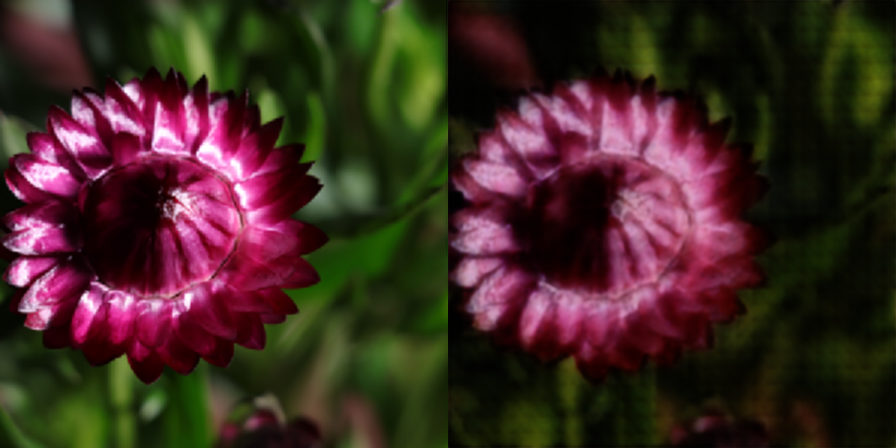

In [10]:
from PIL import Image
import numpy as np


# Helper: Convert tensor [H, W, C] in [0,1] float32 to uint8
def tensor_to_uint8_img(t):
    arr = t.permute(1, 2, 0).cpu().detach().numpy()
    arr = np.clip(arr, 0, 1)
    arr = (arr * 255).round().astype(np.uint8)
    return arr


for input_batch, output_batch in zip(loader, output_images):
    concat_images = torch.cat(
        [input_batch.cpu(), output_batch.cpu()], dim=3
    )  # (B, 3, H, 2W)
    for sample in concat_images:
        img_uint8 = tensor_to_uint8_img(sample)
        display(Image.fromarray(img_uint8))
    break
